**Modelo de regresion para predecir el exito de una articulo antes de lanzarlo**


Motivación: En un mercado tan competitivo como el de E-commerce, entender qué factores (precio, descuento, categoría) influyen en la satisfacción del cliente (Rating) es vital para sobrevivir

Beneficios de la IA: A diferencia de un análisis manual, un modelo de Machine Learning puede identificar patrones no lineales entre miles de productos para predecir el éxito de un artículo antes de lanzarlo

Contexto Local: Aplicar estos modelos en emprendimientos de Santander permitiría a comerciantes locales optimizar sus precios en plataformas digitales para competir con grandes superficies.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch

df = pd.read_csv("https://raw.githubusercontent.com/davidChaparro09/Proyecto-de-IA_-Regresion-para-predecir-el-exito-de-un-articulo/refs/heads/main/Data/amazon_sales_dataset.csv")
print("Dimensiones del dataset:", df.shape)
print("\nTipos de datos originales:")
print(df.dtypes)
print("\nValores nulos por columna:")
print(df.isnull().sum())
df.head()

Dimensiones del dataset: (50000, 13)

Tipos de datos originales:
order_id              int64
order_date           object
product_id            int64
product_category     object
price               float64
discount_percent      int64
quantity_sold         int64
customer_region      object
payment_method       object
rating              float64
review_count          int64
discounted_price    float64
total_revenue       float64
dtype: object

Valores nulos por columna:
order_id            0
order_date          0
product_id          0
product_category    0
price               0
discount_percent    0
quantity_sold       0
customer_region     0
payment_method      0
rating              0
review_count        0
discounted_price    0
total_revenue       0
dtype: int64


,order_id,order_date,product_id,product_category,price,discount_percent,quantity_sold,customer_region,payment_method,rating,review_count,discounted_price,total_revenue
0,1,2022-04-13,2637,Books,128.75,10,4,North America,UPI,3.5,443,115.88,463.52
1,2,2023-03-12,2300,Fashion,302.60,20,5,Asia,Credit Card,3.7,475,242.08,1210.40
2,3,2022-09-28,3670,Sports,495.80,20,2,Europe,UPI,4.4,183,396.64,793.28
3,4,2022-04-17,2522,Books,371.95,15,4,Middle East,UPI,5.0,212,316.16,1264.64
4,5,2022-03-13,1717,Beauty,201.68,0,4,Middle East,UPI,4.6,308,201.68,806.72


Eliminaremos columnas como order_id, product_id que no nos brindan informacion util para la regresion


In [ ]:
print("Valores únicos en product_id:", df['product_id'].nunique())
columnas_a_eliminar = ['order_id', 'product_id']
df = df.drop(columns=columnas_a_eliminar)

Valores únicos en product_id: 4000


En este caso el dataset ya tiene cierta limpieza en sus datos como el price no tiene simbolos como $, ₹ o similar, los datos son float, o enteros menos order_date, product_category, customer_region y payment_method que son caracteres estos si debemos convertirlos a numeros

y en el caso de order_date tomaremos solo los meses y lo convertiremos a un valor numerico

In [ ]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
print("Valores únicos en product_category:", df['product_category'].unique())
df['product_category'] = le.fit_transform(df['product_category'])
print("Valores únicos numericos en product_category:", df['product_category'].unique())

print("Valores únicos en customer_region:", df['customer_region'].unique())
df['customer_region'] = le.fit_transform(df['customer_region'])
print("Valores únicos numericos en customer_region:", df['customer_region'].unique())

print("Valores únicos en payment_method:", df['payment_method'].unique())
df['payment_method'] = le.fit_transform(df['payment_method'])
print("Valores únicos numericos en payment_method:", df['payment_method'].unique())

Valores únicos en product_category: ['Books' 'Fashion' 'Sports' 'Beauty' 'Electronics' 'Home & Kitchen']
Valores únicos numericos en product_category: [1 3 5 0 2 4]
Valores únicos en customer_region: ['North America' 'Asia' 'Europe' 'Middle East']
Valores únicos numericos en customer_region: [3 0 1 2]
Valores únicos en payment_method: ['UPI' 'Credit Card' 'Wallet' 'Cash on Delivery' 'Debit Card']
Valores únicos numericos en payment_method: [3 1 4 0 2]


In [ ]:
df['mes'] = pd.to_datetime(df['order_date']).dt.month.astype(int)
df = df.drop(columns=['order_date'])
df.head()

,product_category,price,discount_percent,quantity_sold,customer_region,payment_method,rating,review_count,discounted_price,total_revenue,mes
0,1,128.75,10,4,3,3,3.5,443,115.88,463.52,4
1,3,302.60,20,5,0,1,3.7,475,242.08,1210.40,3
2,5,495.80,20,2,1,3,4.4,183,396.64,793.28,9
3,1,371.95,15,4,2,3,5.0,212,316.16,1264.64,4
4,0,201.68,0,4,2,3,4.6,308,201.68,806.72,3


ahora analizaremos algunas graficas para ver el comportamiento de los datos





## **Categorias de productos y regiones atendidas**

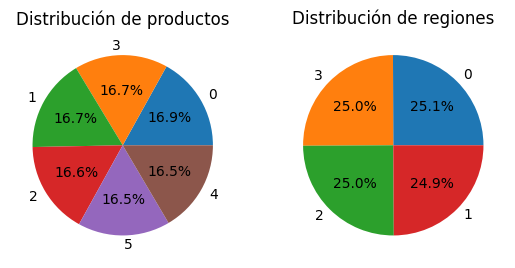

In [ ]:
counts = df['product_category'].value_counts()
plt.subplot(1,2,1)
plt.pie(
    counts,
    labels=counts.index,
    autopct='%1.1f%%'
)

plt.title('Distribución de productos')


plt.subplot(1,2,2)
counts = df['customer_region'].value_counts()

plt.pie(
    counts,
    labels=counts.index,
    autopct='%1.1f%%'
)

plt.title('Distribución de regiones')
plt.show()

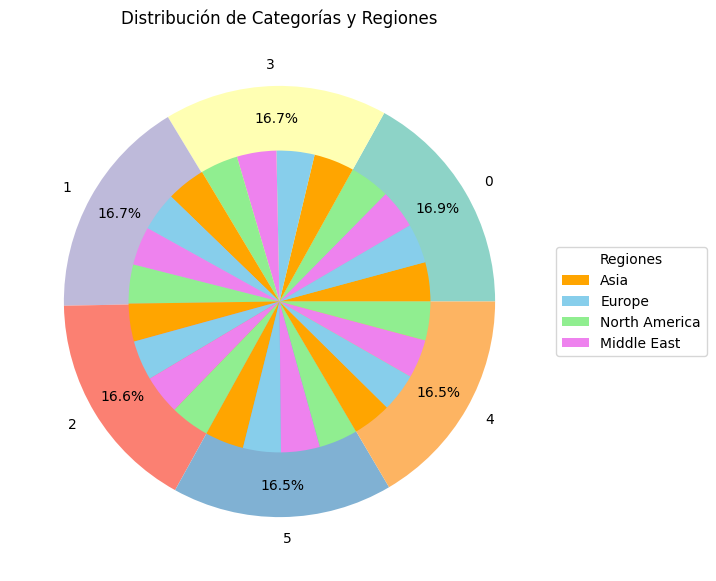

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

cat_counts = df['product_category'].value_counts()

# conteo por categoria y region
region_counts = df.groupby(['product_category','customer_region']).size()

fig, ax = plt.subplots(figsize=(7,7))

# colores para categorias
colors_cat = plt.cm.Set3.colors[:len(cat_counts)]

# pie exterior (categorias)
ax.pie(
    cat_counts,
    radius=1,
    labels=cat_counts.index,
    autopct='%1.1f%%',
    pctdistance=0.85,
    colors=colors_cat
)

# definir colores fijos para regiones usando los valores numéricos codificados
region_colors = {
    0: 'orange',  # Corresponde a Asia
    1: 'skyblue', # Corresponde a Europe
    2: 'violet',  # Corresponde a Middle East
    3: 'lightgreen' # Corresponde a North America
}

# obtener lista de regiones en orden
regions = region_counts.index.get_level_values(1)

# asignar colores según region
inner_colors = [region_colors[r] for r in regions]

# pie interior (sin etiquetas)
ax.pie(
    region_counts,
    radius=0.7,
    labels=None,
    colors=inner_colors
)

# crear leyenda de regiones (usando los nombres originales para la leyenda)
# Para la leyenda, necesitamos revertir la codificación o tener un mapeo de número a nombre original
# Ya que no tenemos el LabelEncoder a mano para el mapeo inverso aquí,
# usaremos los nombres originales del diccionario para la leyenda para mayor claridad.
legend_elements = [
    Patch(facecolor='orange', label='Asia'),
    Patch(facecolor='skyblue', label='Europe'),
    Patch(facecolor='lightgreen', label='North America'),
    Patch(facecolor='violet', label='Middle East')
]

ax.legend(
    handles=legend_elements,
    title="Regiones",
    loc="center left",
    bbox_to_anchor=(1,0.5)
)

plt.title("Distribución de Categorías y Regiones")
plt.show()

<Axes: xlabel='discount_percent', ylabel='total_revenue'>

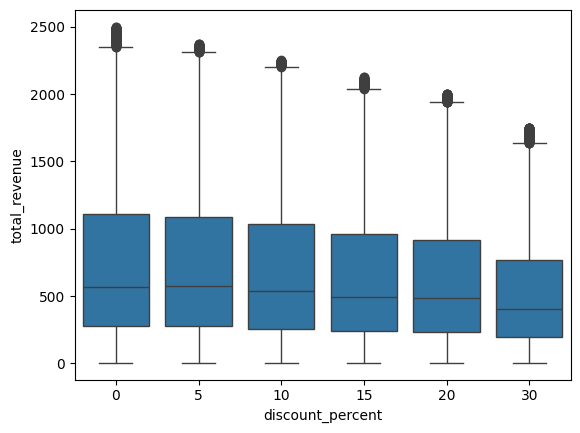

In [ ]:
sns.boxplot(x = 'discount_percent',y= 'total_revenue',data =df)

## **

## **Histograma de precios con descuento**

Para hacer el modelo se necesita conocer la distribución de la frecuencia de los precios con descuento y posteriormente determinar si es necesario transformar los datos para normalizarlos o no, con el fin de que el modelo pueda predecir el exito de forma efectiva.

En este caso, no es necesario transformar estos datos debido a que los datos no tienen una asimetria muy fuerte, es decir, no hay outliers ni colas demasiado altas.



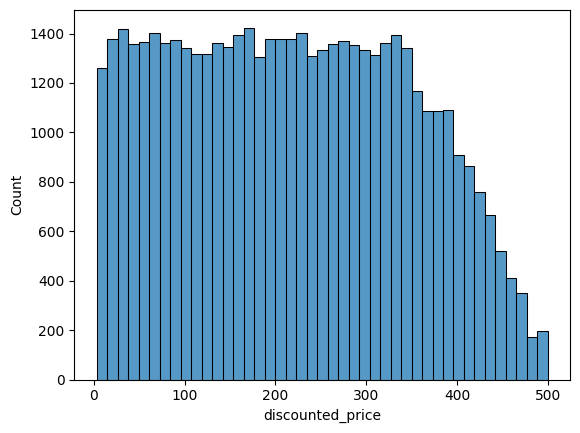

In [ ]:
descuento = sns.histplot(df.discounted_price)

## **Gráfica de precio con descuento vs ingresos totales**

El gráfico muestra la relación entre el precio con descuento (discounted_price) y los ingresos totales (total_revenue). Se observa una relación lineal creciente, esto se debe a que  el ingreso total se calcula como el producto entre el precio del producto y la cantidad de unidades vendidas. Las distintas líneas diagonales representan diferentes niveles de unidades vendidas (quantity_sold).

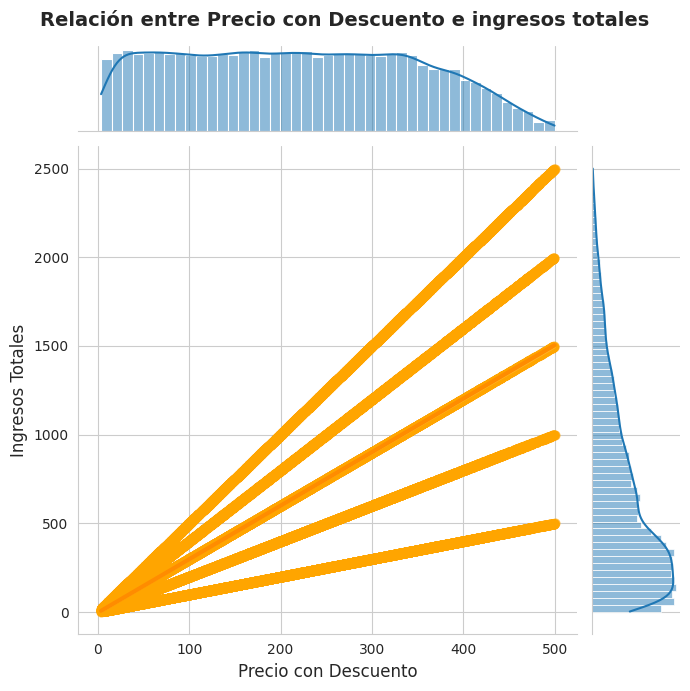

In [ ]:
# @title
sns.set_style("whitegrid")

g = sns.jointplot(
    x="discounted_price",
    y="total_revenue",
    data=df,
    kind="reg",
    height=7,
    scatter_kws={
        "color": "orange",
        "alpha": 0.6,
        "s": 40
    },
    line_kws={
        "color": "darkorange",
        "linewidth": 3
    }
)

g.set_axis_labels("Precio con Descuento", "Ingresos Totales", fontsize=12)

plt.suptitle("Relación entre Precio con Descuento e ingresos totales",
             fontsize=14,
             fontweight="bold")

plt.tight_layout()
plt.show()

## **Matriz de correlación**


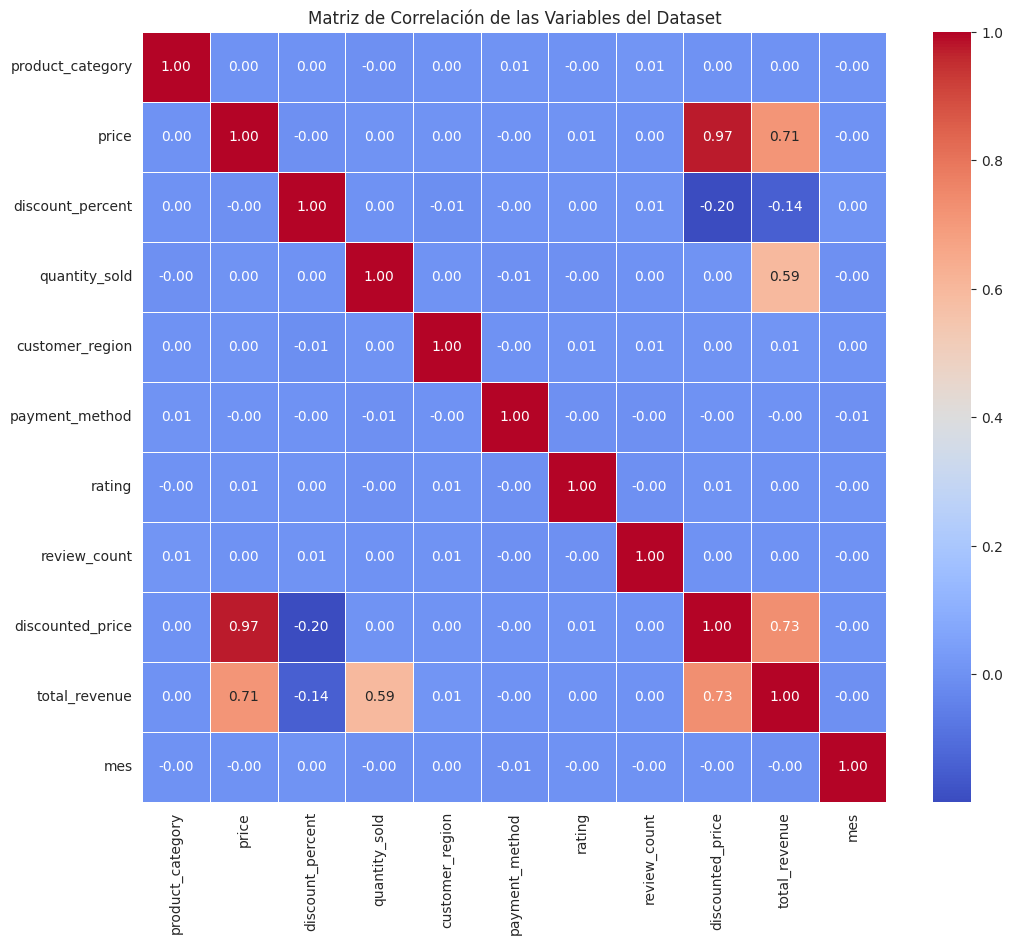

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Crear un mapa de calor (heatmap)
plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Matriz de Correlación de las Variables del Dataset')
plt.show()

### Definir X (características) y y (target: Rating)

In [ ]:
X = df.drop('rating', axis=1)
y = df['rating']

### Particionado 80/20 + shuffle

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Partición
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, shuffle=True, random_state=42)

# Escalar los datos (importante para SVM y Redes Neuronales)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Modelado, cross validation y Deep Learning: Perceptrón Multicapa (MLP)

In [ ]:
# @title Evaluación de Modelos
from sklearn.model_selection import cross_validate
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
import pandas as pd
from sklearn.svm import LinearSVR
import numpy as np

# Definimos los modelos con sus parámetros optimizados
modelos = {
    "Decision Tree": DecisionTreeRegressor(max_depth=10, random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=10, n_jobs=-1, random_state=42),
    "SVR (SVM)":LinearSVR(epsilon=0.1, C=0.5, max_iter=10000, dual='auto'),
    "MLP (Neural Net)": MLPRegressor(hidden_layer_sizes=(64, 128, 128), max_iter=100, early_stopping=True, random_state=42)
}

# Definimos las métricas
metrics = ['neg_mean_absolute_error', 'neg_mean_squared_error', 'neg_root_mean_squared_error']
resultados_lista = []

print("=== INICIANDO PROCESAMIENTO ===")

for nombre, modelo in modelos.items():
    print(f"Calculando {nombre}...")

    # Ejecutamos la validación cruzada una sola vez por modelo
    cv_results = cross_validate(modelo, X_train_scaled, y_train, cv=10, scoring=metrics, n_jobs=-1)

    # Guardamos los promedios (multiplicamos por -1 porque sklearn devuelve valores negativos)
    resultados_lista.append({
        "Modelo": nombre,
        "MAE": -cv_results['test_neg_mean_absolute_error'].mean(),
        "MSE": -cv_results['test_neg_mean_squared_error'].mean(),
        "RMSE": -cv_results['test_neg_root_mean_squared_error'].mean()
    })

# Creación de la Tabla Comparativa
df_resultados = pd.DataFrame(resultados_lista)
print("\n", df_resultados)

=== INICIANDO PROCESAMIENTO ===
Calculando Decision Tree...
Calculando Random Forest...
Calculando SVR (SVM)...
Calculando MLP (Neural Net)...

              Modelo       MAE       MSE      RMSE
0     Decision Tree  1.012186  1.379426  1.174452
1     Random Forest  1.043744  1.507819  1.227918
2         SVR (SVM)  1.000523  1.331160  1.153741
3  MLP (Neural Net)  1.003443  1.344171  1.159361


In [ ]:
# Entrenamos los modelos una última vez con todo el set de entrenamiento
# para poder usarlos en las gráficas de residuos y predicción
dt_model = modelos["Decision Tree"].fit(X_train_scaled, y_train)
rf_model = modelos["Random Forest"].fit(X_train_scaled, y_train)
svr_model = modelos["SVR (SVM)"].fit(X_train_scaled, y_train)
mlp_model = modelos["MLP (Neural Net)"].fit(X_train_scaled, y_train)

MAE (Error Absoluto Medio): Te dice, en promedio, qué tan "lejos" está la predicción del rating real. Si el MAE es 0.5, significa que tus predicciones fallan por medio punto de calificación en promedio.  

RMSE (Raíz del Error Cuadrático Medio): Es más estricto con los errores grandes. Si un comerciante de Santander tiene un producto con un rating muy distinto al esperado, el RMSE lo penalizará más que el MAE.  

MSE (Error Cuadrático Medio): Es la base matemática, pero el RMSE es más fácil de interpretar porque está en la misma unidad que el rating

Menos error = Mayor precisión: Si el SVM (SVR) tiene los valores más bajos, significa que sus predicciones fallaron menos en comparación con los otros modelos.  

Interpretación del MAE: Si el SVM tiene un MAE de 0.2, significa que, en promedio, se equivoca solo en 0.2 puntos de la escala de rating de los productos.  

Interpretación del RMSE: Al ser el más bajo, también te indica que el SVM tiene menos "predicciones desastrosas" o errores muy grandes comparado con Random Forest o los demás.

### Gráficas de Resultados

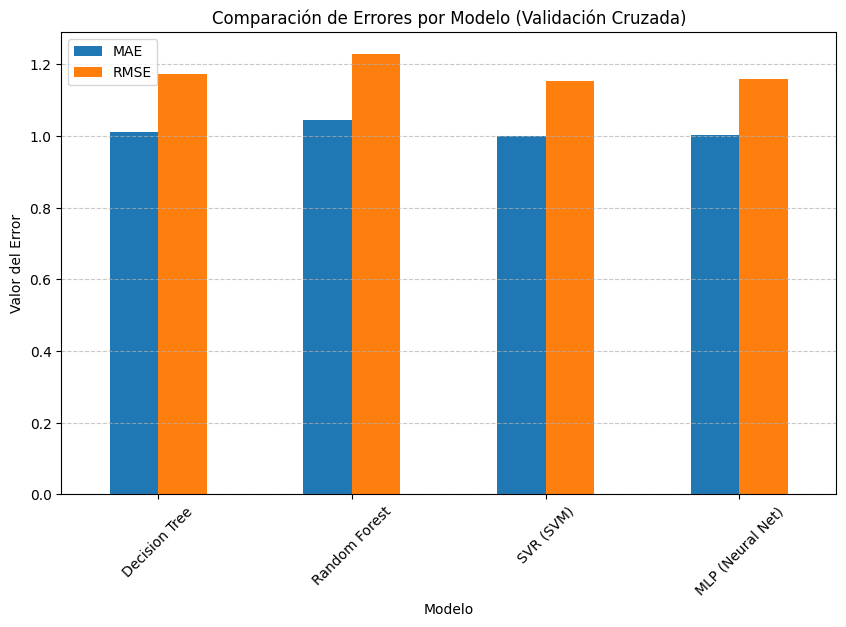

In [ ]:
import matplotlib.pyplot as plt

# Configuramos la gráfica
df_resultados.set_index('Modelo')[['MAE', 'RMSE']].plot(kind='bar', figsize=(10, 6))
plt.title('Comparación de Errores por Modelo (Validación Cruzada)')
plt.ylabel('Valor del Error')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

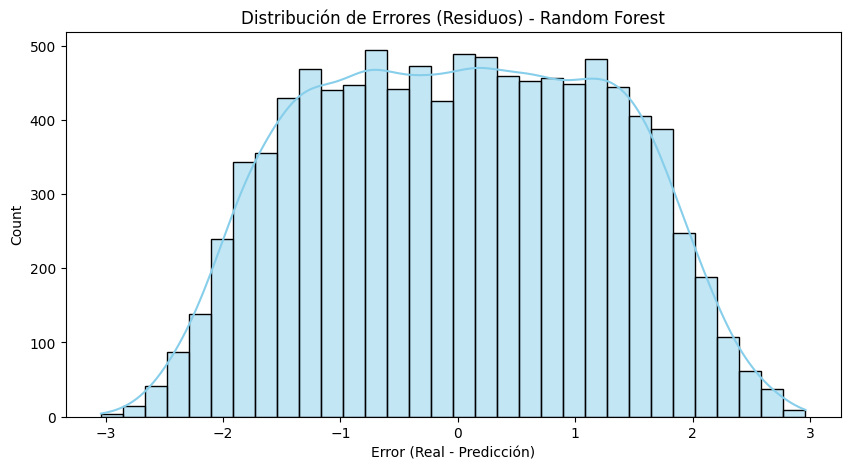

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Histogramas de Residuos
plt.figure(figsize=(10, 5))
residuos = y_test - rf_model.predict(X_test_scaled)
sns.histplot(residuos, kde=True, color="skyblue")
plt.title("Distribución de Errores (Residuos) - Random Forest")
plt.xlabel("Error (Real - Predicción)")
plt.show()

Se suele usar Random Forest para el análisis de residuos porque es un modelo balanceado: no es tan propenso al sobreajuste como el Árbol de Decisión simple y es más fácil de interpretar que una caja negra como el MLP

Esa forma de "meseta" (valores constantes entre -1.7 y 1.7 que luego caen) sugiere que el modelo tiene una incertidumbre uniforme en el rango central del rating.
Hay "ruido" en los datos que impide que el modelo sea más específico en el centro de la distribución

El ruido ocurre cuando el rating de un producto depende de cosas que el modelo no puede ver.
Dos productos en Santander pueden tener el mismo precio, la misma categoría y haberse vendido en el mismo mes, pero uno tiene 4.5 de rating porque el empaque era hermoso y el otro tiene 2.0 porque llegó roto

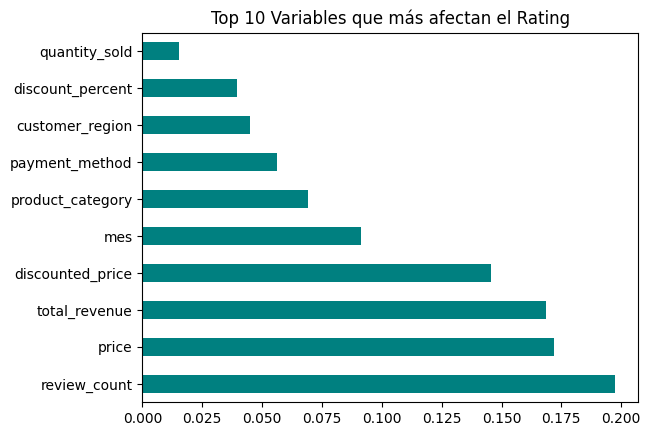

In [ ]:
# Importancia de Variables (Solo para RF/DT)
importancia = pd.Series(rf_model.feature_importances_, index=X.columns)
importancia.nlargest(10).plot(kind='barh', color='teal')
plt.title("Top 10 Variables que más afectan el Rating")
plt.show()

Por qué solo RF/DT para importancia: Estos modelos calculan cuánta "pureza" aporta cada variable al dividir los datos. SVM o MLP no tienen una forma nativa tan directa de mostrar esto.

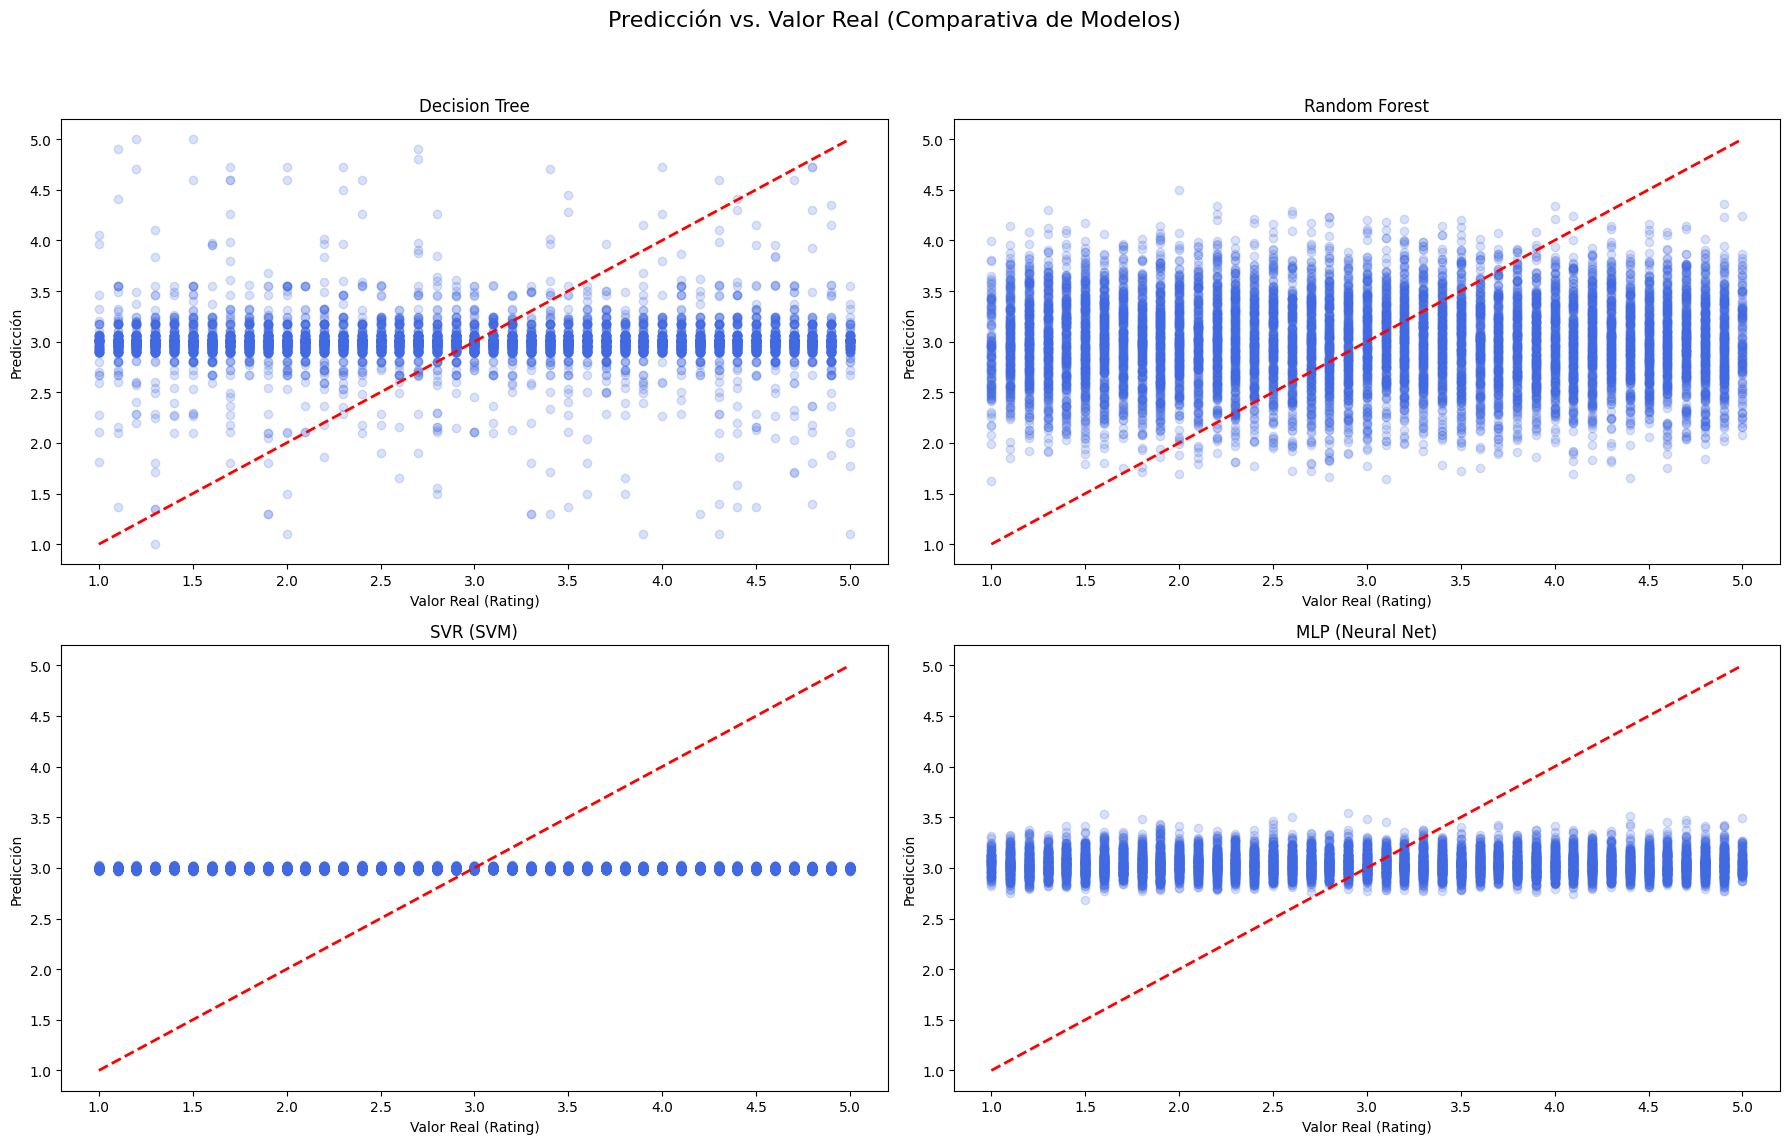

In [52]:
# Creamos una cuadrícula de gráficas (2 filas, 2 columnas)
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('Predicción vs. Valor Real (Comparativa de Modelos)', fontsize=16)

modelos_lista = [
    (dt_model, "Decision Tree", axes[0, 0]),
    (rf_model, "Random Forest", axes[0, 1]),
    (svr_model, "SVR (SVM)", axes[1, 0]),
    (mlp_model, "MLP (Neural Net)", axes[1, 1])
]

for modelo, nombre, ax in modelos_lista:
    y_pred = modelo.predict(X_test_scaled)
    ax.scatter(y_test, y_pred, alpha=0.2, color='royalblue')
    # Línea de perfección (45 grados)
    ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
    ax.set_title(f'{nombre}')
    ax.set_xlabel('Valor Real (Rating)')
    ax.set_ylabel('Predicción')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

una línea horizontal cerca de 2.5 - 3.5 mientras la línea roja va a 45°, significa que el modelo está prediciendo el promedio para casi todo.

El modelo no encontró patrones fuertes en tus variables (precio, categoría, mes) para diferenciar un producto de 1 estrella de uno de 5 estrellas
Ante la duda, el modelo "apuesta a lo seguro" y lanza una predicción cercana a la media del dataset para minimizar el error total

Los modelos demuestran que el rating de los productos en este dataset de E-commerce es difícil de predecir solo con variables básicas, sugiriendo que factores externos (calidad del servicio, envío, marketing) tienen un peso mayor que el precio o la categoría

Al haber tantos datos (50,000) con características similares pero ratings distintos, el modelo simplemente "se rinde" de intentar ser específico y asigna un valor promedio

### quitar el review count

In [ ]:
# Quitar la variable problemática (Fuga de datos)
X_nuevo = X.drop(columns=['review_count'], errors='ignore')

# Re-particionar y re-escalar
from sklearn.model_selection import train_test_split
X_train_n, X_test_n, y_train_n, y_test_n = train_test_split(X_nuevo, y, test_size=0.2, random_state=42)

# Es vital usar un nuevo escalador para evitar contaminar los datos
from sklearn.preprocessing import StandardScaler
scaler_n = StandardScaler()
X_train_scaled_n = scaler_n.fit_transform(X_train_n)
X_test_scaled_n = scaler_n.transform(X_test_n)

# Entrenar el MEJOR modelo (MLP) sin esa variable
# Usamos la misma configuración que en la validación cruzada
mlp_final = MLPRegressor(
    hidden_layer_sizes=(64, 128, 128), max_iter=100, early_stopping=True, random_state=42
)

mlp_final.fit(X_train_scaled_n, y_train_n)
y_pred_n = mlp_final.predict(X_test_scaled_n)

# 4. Comparar métricas finales
from sklearn.metrics import mean_absolute_error, r2_score
print("=== RESULTADOS FINALES (SIN REVIEW_COUNT) ===")
print(f"Nuevo MAE con MLP: {mean_absolute_error(y_test_n, y_pred_n):.4f}")

=== RESULTADOS FINALES (SIN REVIEW_COUNT) ===
Nuevo MAE con MLP: 1.0064


como el MAE subio podriamos decir que refleja la realidad de qué tan difícil es predecir el éxito sin saber cuántas reseñas tendrá el producto

### conclusion

Sí, son datos reales, pero la realidad es compleja. En el E-commerce, el éxito de un producto (el rating) rara vez se explica solo por el precio o la categoría. El "ruido" es la prueba estadística de que faltan variables explicativas o que la opinión humana tiene un componente subjetivo que ninguna máquina puede predecir con total exactitud solo con esos datos.

**Tomando quantity_sold como ground truth**

In [ ]:
X2 = df.drop('quantity_sold', axis=1)
Y2 = df['quantity_sold']
from sklearn.svm import SVR
from sklearn.metrics import *
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Partición
X_train2, X_test2, y_train2, y_test2 = train_test_split(X2, Y2, test_size=0.20, shuffle=True, random_state=42)

# Escalar los datos (importante para SVM y Redes Neuronales)
#scaler = StandardScaler()
#X_train_scaled = scaler.fit_transform(X_train)
#X_test_scaled = scaler.transform(X_test)

In [ ]:
#@title **code** learning curve
def show_curve(est,metric):
    means, stds = [], []
    mean =0
    nfolds_range = range(2,10)
    for nfolds in nfolds_range:
        #print (nfolds,)
        s = cross_val_score(est, X2, Y2, cv=KFold(nfolds, shuffle=True), scoring=make_scorer(metric) )
        mean = np.mean(s)
        means.append(np.mean(s))
        stds.append(np.std(s))

    means = np.r_[means]
    stds  = np.r_[stds]

    plt.plot(nfolds_range, means, label="mean", color="black")
    plt.fill_between(nfolds_range, means-stds, means+stds, color="blue", alpha=.5, label="std")
    plt.xlabel("n folds")
    plt.ylabel("performance")
    plt.legend()
    return mean

MSE depth split data  0.004
RMSE depth split data  0.066
MAE depth split data  0.006

Metricas promedio usando cross validation con 9 kfolds:
MSE promedio 0.004281
RMSE promedio 0.065431
MAE promedio  0.006923


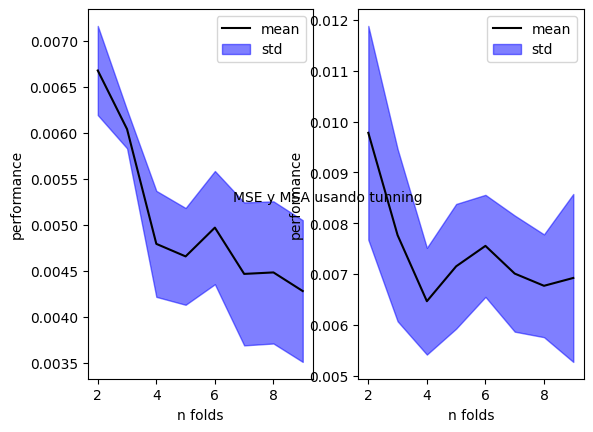

In [ ]:
#@title **code** using DTR with 4 and 10 in max_depth



DT2 = DecisionTreeRegressor(max_depth = 10, random_state=42)



plt.subplot(1,2,1)
plt.figtext(0.5, 0.48, "MSE y MSA usando tunning", ha="center")
DT2_MSE = show_curve(DT2,mean_squared_error)
plt.subplot(1,2,2)
DT2_MSA= show_curve(DT2,mean_absolute_error)

DT2 = DecisionTreeRegressor(max_depth = 10, random_state=42)
DT2.fit(X_train2,y_train2)
print("MSE depth split data  %.3f"% mean_squared_error(y_test2, DT2.predict(X_test2)))
print("RMSE depth split data  %.3f"% np.sqrt(mean_squared_error(y_test2, DT2.predict(X_test2))))
print("MAE depth split data  %.3f"% mean_absolute_error(y_test2, DT2.predict(X_test2)))
print()
print("Metricas promedio usando cross validation con 9 kfolds:")
print("MSE promedio %.6f"%DT2_MSE)
print("RMSE promedio %.6f"% np.sqrt(DT2_MSE))
print("MAE promedio  %.6f"% DT2_MSA)

np.float64(0.003303977625984343)

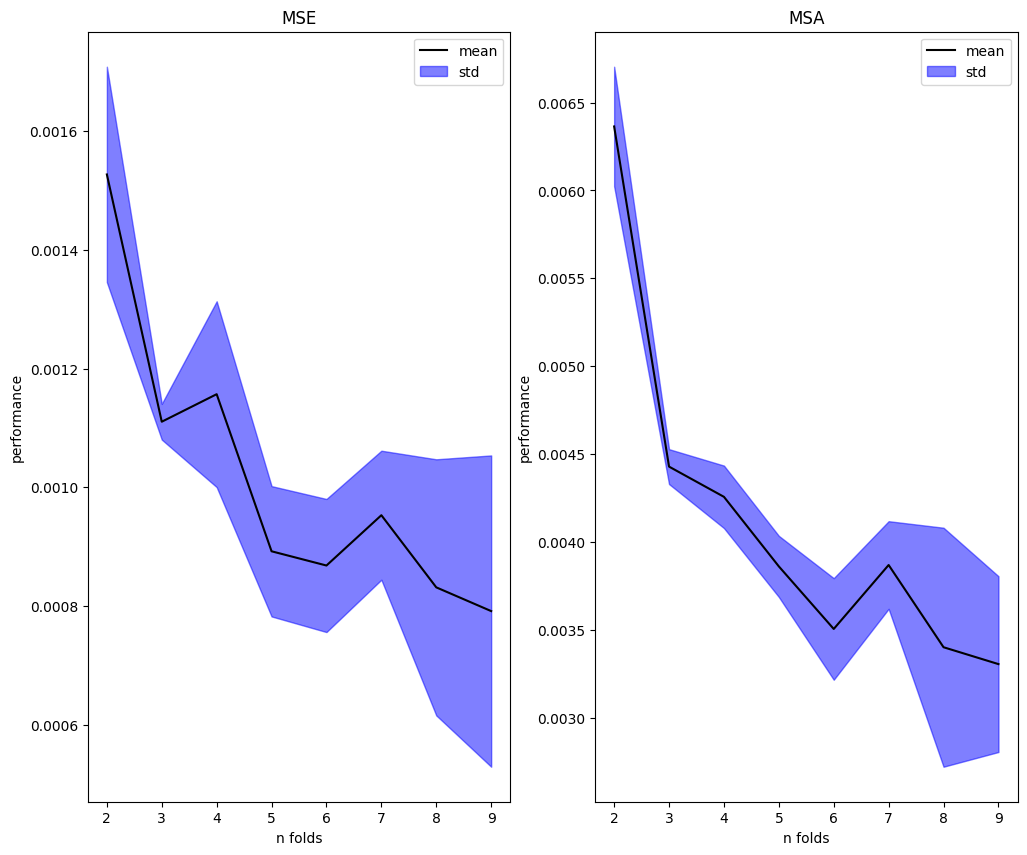

In [ ]:
#@title **code** using RF with 5 stimators
plt.figure(figsize=(12, 10))

plt.subplot(1,2,1)
plt.title("MSE")
RF2 = RandomForestRegressor(n_estimators=5, random_state=42)
show_curve(RF2,mean_squared_error)

plt.subplot(1,2,2)
plt.title("MSA")
RF2 = RandomForestRegressor(n_estimators=5, random_state=42)
show_curve(RF2,mean_absolute_error)



In [ ]:
#@title **code student**




regressor = SVR(kernel = "rbf")
regressor.fit(X_train2, y_train2)

print("MSE depth split data  %.3f"% mean_squared_error(y_test2, regressor.predict(X_test2)))
print("RMSE depth split data  %.3f"% np.sqrt(mean_squared_error(y_test2, regressor.predict(X_test2))))
print("MAE depth split data  %.3f"% mean_absolute_error(y_test2, regressor.predict(X_test2)))

## tercera entrega

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN

X2 = df.drop('quantity_sold', axis=1)
Y2 = df['quantity_sold']

#  Escalado con MinMaxScaler
scaler_minmax = MinMaxScaler()
X_scaled = scaler_minmax.fit_transform(X2)
print("Datos preparados y escalados correctamente con MinMaxScaler.")

Datos preparados y escalados correctamente con MinMaxScaler.


X:  (50000, 10)  X_pca:  (50000, 2)
Varianza total explicada por las 2 componentes de PCA: 0.3339


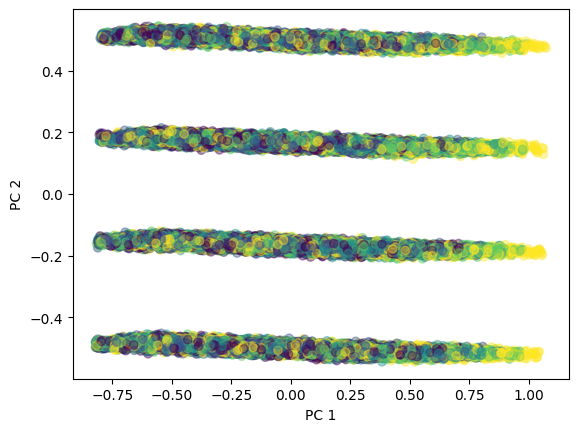

In [ ]:
# Reducción a 2 dimensiones para poder visualizar los clústeres en una gráfica
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
print('X: ', X2.shape, ' X_pca: ', X_pca.shape)
plt.scatter(X_pca[:,0],X_pca[:,1],c=Y2, alpha=0.4)
plt.xlabel("PC 1"); plt.ylabel("PC 2")

# Convertimos a DataFrame para facilitar las gráficas
df_pca = pd.DataFrame(data=X_pca, columns=['Componente_Principal_1', 'Componente_Principal_2'])

# Agregamos la columna original quantity_sold
df_pca['quantity_sold'] = df['quantity_sold'].values

print(f"Varianza total explicada por las 2 componentes de PCA: {sum(pca.explained_variance_ratio_):.4f}")

In [ ]:
# Configuración del modelo K-Means
num_clusters = 3 # Puedes cambiar este número según consideres
kmeans = KMeans(n_clusters=num_clusters, init='k-means++', random_state=42, n_init=10)

# Ajustar y predecir los grupos
df_pca['Cluster_KMeans'] = kmeans.fit_predict(X_scaled)

print("K-Means ejecutado correctamente.")



K-Means ejecutado correctamente.


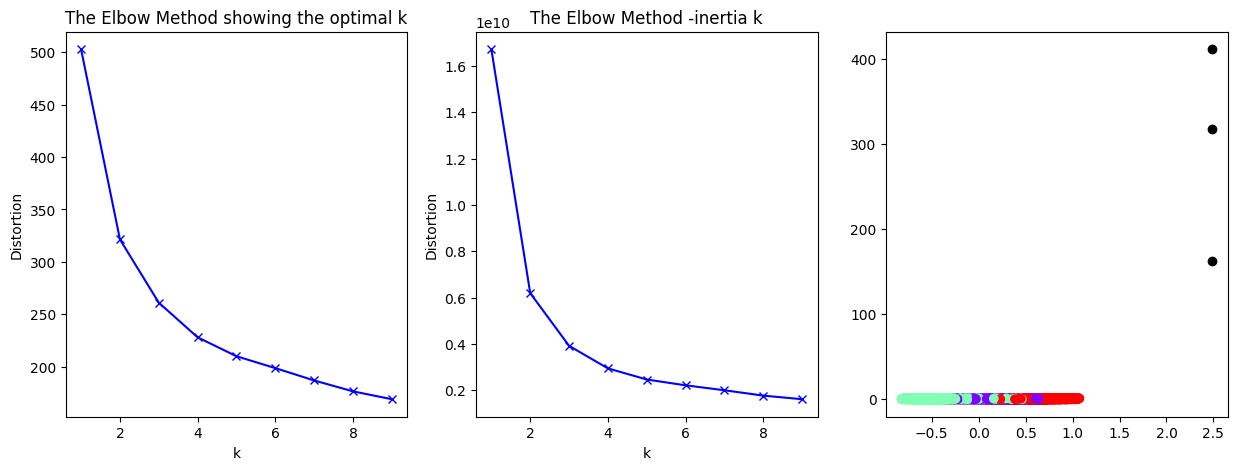

In [ ]:
 #@title Aplicando Kmeans pasandole las 10 columnas y despues se aplica PCA solo para graficar
from scipy.spatial.distance import cdist

distortions = []
wss = [] #Within-Cluster-Sum of Squared
K = range(1,10)
for k in K:
    kmeanModel = KMeans(n_clusters=k, n_init='auto').fit(X2)
    distortions.append(sum(np.min(cdist(X2, kmeanModel.cluster_centers_, 'euclidean'), axis=1)) / X2.shape[0])
    wss.append(kmeanModel.inertia_)

plt.figure(figsize=(15,5))
plt.subplot(131)
plt.plot(K, distortions, 'bx-'); plt.xlabel('k');plt.ylabel('Distortion')
plt.title('The Elbow Method showing the optimal k')
plt.subplot(132)
plt.plot(K, wss, 'bx-'); plt.xlabel('k');plt.ylabel('Distortion')
plt.title('The Elbow Method -inertia k')
plt.subplot(133)
kmeanModel = KMeans(n_clusters=3, n_init='auto').fit(X2)
plt.scatter(X_pca[:,0], X_pca[:,1], c=kmeanModel.labels_, cmap='rainbow');
plt.scatter(kmeanModel.cluster_centers_[:,0] ,kmeanModel.cluster_centers_[:,1], color='black')

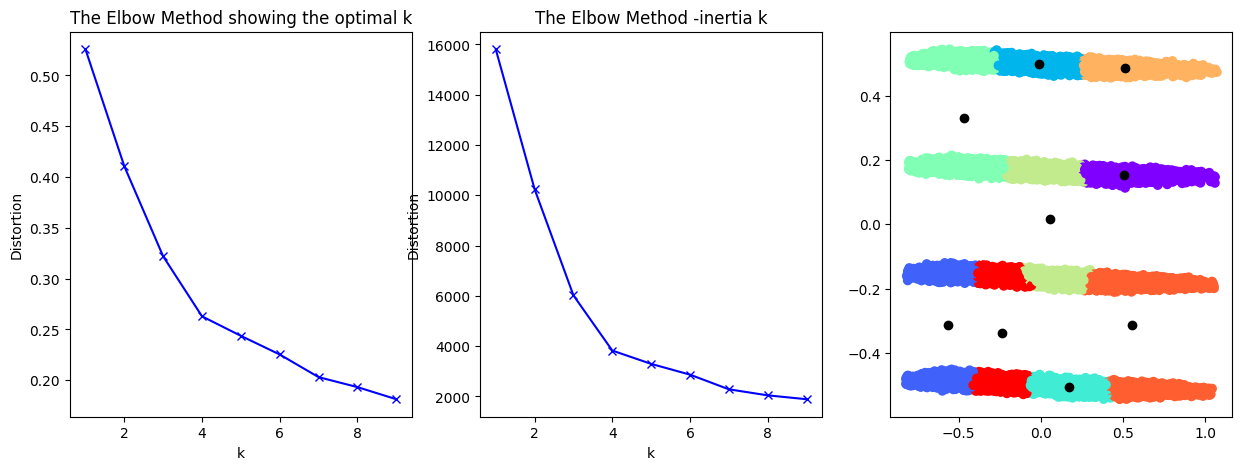

In [ ]:
# Configuración del modelo K-Means
#num_clusters = 3 # Puedes cambiar este número según consideres
#kmeans = KMeans(n_clusters=num_clusters, init='k-means++', random_state=42, n_init=10)

# Ajustar y predecir los grupos
#df_pca['Cluster_KMeans'] = kmeans.fit_predict(X_scaled)

#print("K-Means ejecutado correctamente.")

#@title Aplicando Kmeans pasandole entrenando con el datset reducido con PCA
from scipy.spatial.distance import cdist

distortions = []
wss = [] #Within-Cluster-Sum of Squared
K = range(1,10)
for k in K:
    kmeanModel = KMeans(n_clusters=k, n_init='auto').fit(X_pca)
    distortions.append(sum(np.min(cdist(X_pca, kmeanModel.cluster_centers_, 'euclidean'), axis=1)) / X_pca.shape[0])
    wss.append(kmeanModel.inertia_)

plt.figure(figsize=(15,5))
plt.subplot(131)
plt.plot(K, distortions, 'bx-'); plt.xlabel('k');plt.ylabel('Distortion')
plt.title('The Elbow Method showing the optimal k')
plt.subplot(132)
plt.plot(K, wss, 'bx-'); plt.xlabel('k');plt.ylabel('Distortion')
plt.title('The Elbow Method -inertia k')
plt.subplot(133)
kmeanModel = KMeans(n_clusters=4, n_init='auto').fit(X_pca)
plt.scatter(X_pca[:,0], X_pca[:,1], c=kmeanModel.labels_, cmap='rainbow');
plt.scatter(kmeanModel.cluster_centers_[:,0] ,kmeanModel.cluster_centers_[:,1], color='black')

/tmp/ipykernel_1868/2232849313.py:6: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(X_pca[:,0], X_pca[:,1], c="blue", cmap='rainbow');


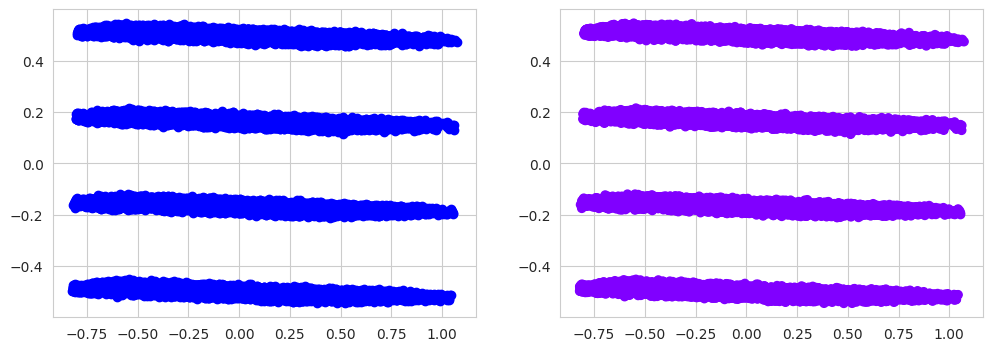

In [ ]:
#@title Aplicando DBScan
dbscan = DBSCAN(eps=0.3, min_samples=5)
dbscan.fit(X_pca)
plt.figure(figsize=(12,4))
plt.subplot(121)
plt.scatter(X_pca[:,0], X_pca[:,1], c="blue", cmap='rainbow');
plt.subplot(122)
plt.scatter(X_pca[:,0],X_pca[:,1], c=dbscan.labels_, cmap='rainbow');

Al configurar un radio de búsqueda de 0.3, el círculo de vecindad de la franja inferior era tan grande que alcanzaba a tocar y absorber los puntos de la franja inmediatamente superior

/tmp/ipykernel_1868/2200261848.py:6: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(X_pca[:,0], X_pca[:,1], c="blue", cmap='rainbow');


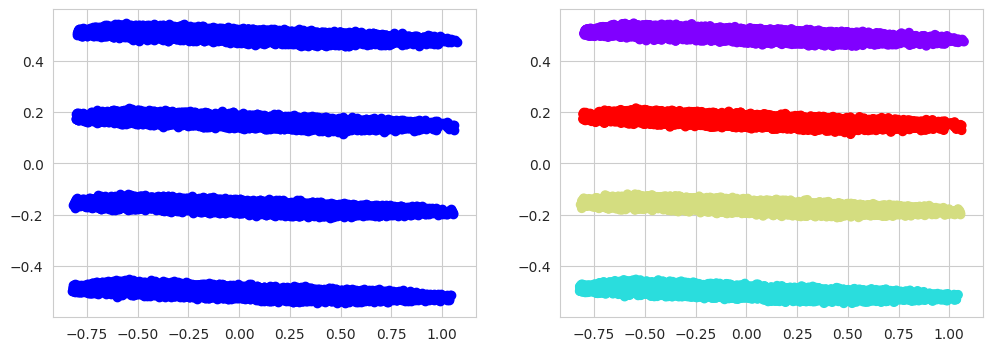

In [ ]:
#@title Aplicando DBScan
dbscan = DBSCAN(eps=0.1, min_samples=5)
dbscan.fit(X_pca)
plt.figure(figsize=(12,4))
plt.subplot(121)
plt.scatter(X_pca[:,0], X_pca[:,1], c="blue", cmap='rainbow');
plt.subplot(122)
plt.scatter(X_pca[:,0],X_pca[:,1], c=dbscan.labels_, cmap='rainbow');